Benjamin Arnold; 09/27/2026; Lab 05-- Orbital Mechanics Simulator

Part A-- A Single Orbit with Velocity Verlet

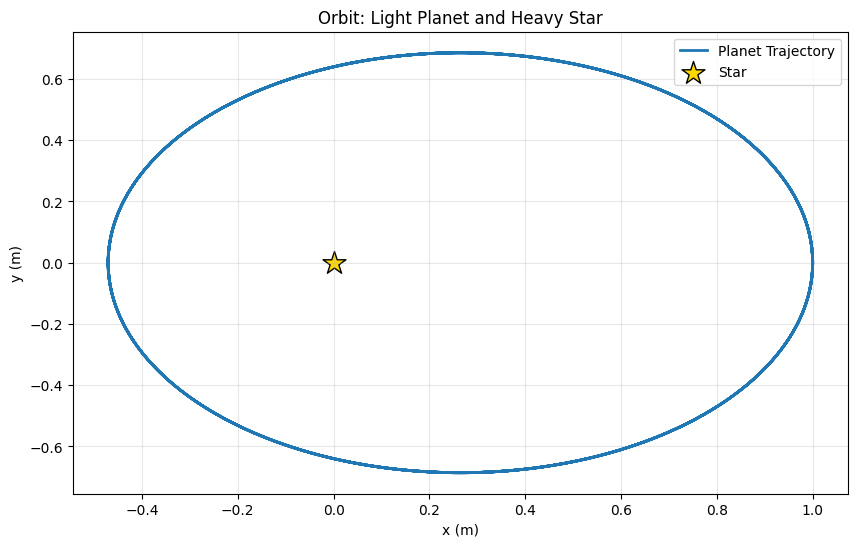

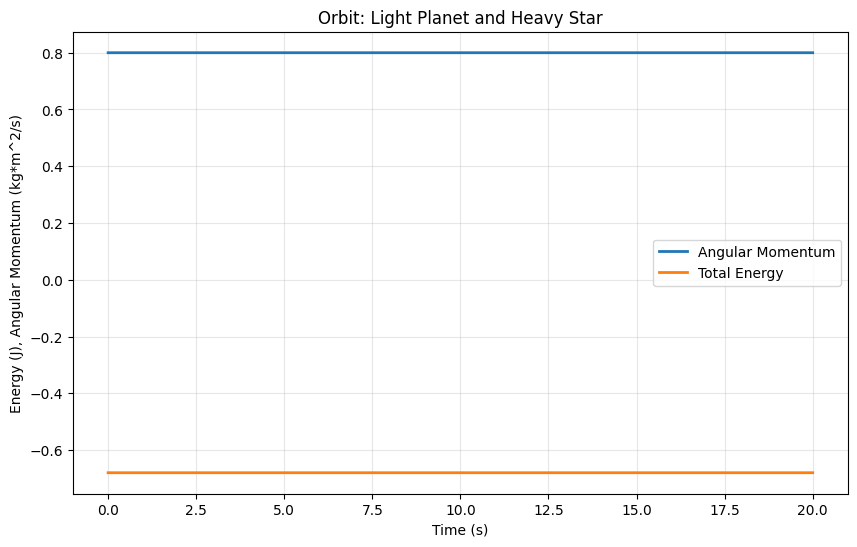

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
G=1.0
M=1.0

def gravity(r1, r2, m1, m2, G=1.0):
    d=np.asarray(r2)-np.asarray(r1)
    dist=np.linalg.norm(d)
    return G*m1*m2*d/dist**3

def energy(r,v,G=G,M=M,m=1.0):
    KE=0.5*m*np.dot(v, v)
    PE=-G*M*m/np.linalg.norm(r)
    return (KE+PE)

def ang_momentum(r,v,m=1.0):
    return m*(r[0]*v[1]-r[1]*v[0])

def accel(r):
    dist=np.linalg.norm(r)
    return -G*M*r/dist**3

def verlet_step(r,v,a,dt,accel_func):
    r_new=r+v*dt+0.5*a*dt**2
    a_new=accel_func(r_new)
    v_new=v+0.5*(a+a_new)*dt
    return r_new,v_new,a_new

r=np.array([1.0,0.0])
v=np.array([0.0,0.8])
a=accel(r)

L=np.array(ang_momentum(r,v,m=1.0))
E=np.array(energy(r,v,G,M,m=1.0))

dt=0.001
rs=[r.copy()]
Ls=[L.copy()]
Es=[E.copy()]
for _ in range(20000):
    r,v,a=verlet_step(r,v,a,dt,accel)
    L=ang_momentum(r,v,m=1.0)
    E=energy(r,v,G,M,m=1.0)
    rs.append(r.copy())
    Ls.append(L.copy())
    Es.append(E.copy())
rs=np.array(rs)
Ls=np.array(Ls)
Es=np.array(Es)

t=np.arange(0,20.001,dt)

plt.figure(figsize=(10, 6))
plt.plot(rs[:,0], rs[:,1], linewidth=2, label='Planet Trajectory')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Orbit: Light Planet and Heavy Star')
plt.scatter(0, 0, marker="*", s=300, color="gold", edgecolor="black", label="Star")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t, Ls, linewidth=2, label='Angular Momentum')
plt.plot(t, Es, linewidth=2, label='Total Energy')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J), Angular Momentum (kg*m^2/s)')
plt.title('Orbit: Light Planet and Heavy Star')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Notes: The starting point (0.0,1.0) in the code are at apoapsis (the furthest point from the central body). A body gravitating around a central one moves slower at the apoapsis compared to the periapsis. Kepler's second law, which is essentially just conservation of angular momentum, tells us the area swept out by the orbiting body's displacement vector must be the same for equivalent durations. So, since there is more area near the periapsis, the body must move slower for an equivalent duration at the apoapsis. 

Part B-- The Integrator Showdown

In [ ]:
def simulate(method, dt, n_steps):
    